# Dataset 4 — Crop Yield Prediction
**Final Classical ML Project (Portfolio Level) — Regression**

**Maqsad:** ekin turi, hudud, yil, yog'ingarchilik, harorat va pestitsid ma'lumotlari asosida hosildorlikni (`hg/ha_yield`) bashorat qiluvchi to'liq Machine Learning pipeline (EDA, Data Cleaning, Feature Engineering, Encoding, Regression, Model Comparison, Cross-validation, Hyperparameter Tuning, Feature Importance, Model Interpretation) qurish.

- **Target:** `hg/ha_yield` (hektoram/gektar hosildorlik)
- **Source:** Kaggle — `patelris/crop-yield-prediction-dataset` (`yield_df.csv`)
- **Dropped columns:** `Unnamed: 0` (indeks dublikati)

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

## Part 1 — Data Loading va Dataset haqida umumiy ma'lumot

In [2]:
df_raw = pd.read_csv("data/yield_df.csv")
df = df_raw.drop(columns=["Unnamed: 0"])

print("Shape:", df.shape)
print("Ustunlar soni:", df.shape[1], "| Observationlar soni:", df.shape[0])
df.info()
df.head()

Shape: (28242, 7)
Ustunlar soni: 7 | Observationlar soni: 28242
<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  str    
 1   Item                           28242 non-null  str    
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), str(2)
memory usage: 1.9 MB


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


**Xulosa:** Dataset 28,242 ta observation va (indeks ustunini olib tashlagandan so'ng) 7 ta ustundan iborat: `Area` (hudud/davlat), `Item` (ekin turi), `Year`, `hg/ha_yield` (target), `average_rain_fall_mm_per_year`, `pesticides_tonnes`, `avg_temp`.

### Ustunlar tavsifi
- `Area` — davlat/hudud nomi (categorical, ~100 ta unique qiymat).
- `Item` — ekin turi, masalan Maize, Wheat, Rice, Potatoes (categorical, ~10 ta unique qiymat).
- `Year` — kuzatuv yili (1990–2013 oralig'ida).
- `average_rain_fall_mm_per_year` — o'sha yil/hudud uchun yillik o'rtacha yog'ingarchilik (mm).
- `pesticides_tonnes` — ishlatilgan pestitsid miqdori (tonna).
- `avg_temp` — o'rtacha harorat (°C).
- `hg/ha_yield` — **target**: gektarga to'g'ri keladigan hosildorlik (hektogram/hektar).

### 2. Missing Values Analysis

In [3]:
missing = df.isnull().sum()
print(missing)
print("Jami missing qiymatlar:", missing.sum())

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64
Jami missing qiymatlar: 0


**Xulosa:** Datasetda missing qiymat mavjud emas (0 ta har bir ustunda) — imputatsiya talab qilinmaydi.

### 3. Duplicate Analysis

In [4]:
dup_count = df.duplicated().sum()
print("Duplicate qatorlar soni:", dup_count)
df = df.drop_duplicates().reset_index(drop=True)
print("Tozalashdan keyingi shape:", df.shape)

Duplicate qatorlar soni: 2310
Tozalashdan keyingi shape: (25932, 7)


**Xulosa:** Duplicate qatorlar topilsa olib tashlandi (yuqoridagi hisobotga qarang) — ular xato kiritish yoki bir xil Area/Item/Year uchun bir necha marta yozilgan qatorlar bo'lishi mumkin.

### 4. Numerical Features — statistik ma'lumot

In [5]:
num_cols = ["Year", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp", "hg/ha_yield"]
cat_cols = ["Area", "Item"]
desc = df[num_cols].describe().T[["mean", "50%", "std", "min", "max", "25%", "75%"]]
desc.columns = ["mean", "median", "std", "min", "max", "q25", "q75"]
desc.round(2)

,mean,median,std,min,max,q25,q75
Year,2001.56,2001.00,7.06,1990.00,2013.00,1995.00,2008.00
average_rain_fall_mm_per_year,1146.84,1083.00,717.39,51.00,3240.00,593.00,1668.00
pesticides_tonnes,34782.57,15373.00,57228.57,0.04,367778.00,1597.00,45620.00
avg_temp,20.42,21.42,6.44,1.30,30.65,16.58,26.06
hg/ha_yield,76978.13,39530.00,84647.61,50.00,501412.00,19996.00,104168.00


**Xulosa:** `hg/ha_yield` juda keng diapazonga ega (min~0 dan max~500,000+ gacha) — bu turli ekin turlari (masalan sabzavot vs don) tabiatan farqli hosildorlik shkalasiga ega bo'lgani uchun tabiiy.

### 5. Ekinlar va hududlar

In [6]:
print("Nechta unique ekin turi:", df["Item"].nunique())
print(df["Item"].value_counts())
print("\nNechta unique hudud:", df["Area"].nunique())
print(df["Area"].value_counts().head(10))

Nechta unique ekin turi: 10
Item
Potatoes                3956
Maize                   3824
Wheat                   3539
Rice, paddy             3091
Soybeans                2940
Sorghum                 2770
Sweet potatoes          2593
Cassava                 1889
Yams                     774
Plantains and others     556
Name: count, dtype: int64

Nechta unique hudud: 101
Area
India        3384
Brazil       1854
Mexico       1280
Australia     966
Pakistan      966
Indonesia     816
Japan         784
Turkey        625
Ecuador       621
Canada        552
Name: count, dtype: int64


**Xulosa:** Datasetda bir nechta ekin turi (masalan Maize, Potatoes, Rice, Wheat, Sorghum va h.k.) va ~100 ta davlat/hudud mavjud. Eng ko'p qator soniga ega davlatlar barcha yillar bo'yicha barcha ekin turlari uchun deyarli to'liq ma'lumotga ega.

### 6. Eng yuqori hosildorlikka ega ekinlar va hududlar

In [7]:
avg_yield_by_item = df.groupby("Item")["hg/ha_yield"].mean().sort_values(ascending=False)
print(avg_yield_by_item)

avg_yield_by_area = df.groupby("Area")["hg/ha_yield"].mean().sort_values(ascending=False)
print("\nTop-10 hudud (o'rtacha yield bo'yicha):")
print(avg_yield_by_area.head(10))

Item
Potatoes                198665.725228
Cassava                 145649.692430
Sweet potatoes          119656.515619
Yams                    112105.633075
Plantains and others    106041.320144
Rice, paddy              41296.028470
Maize                    37139.320345
Wheat                    30125.681266
Sorghum                  19099.774729
Soybeans                 16992.190136
Name: hg/ha_yield, dtype: float64

Top-10 hudud (o'rtacha yield bo'yicha):
Area
United Kingdom    240956.478261
Belgium           216468.461538
Denmark           214033.020000
Netherlands       204151.202899
Ireland           197913.695652
New Zealand       191931.826087
Sweden            187405.500000
Bahrain           153237.551724
Norway            146115.326087
Switzerland       144960.282609
Name: hg/ha_yield, dtype: float64


**Xulosa:** Eng yuqori o'rtacha hosildorlikka ega ekin (masalan **Potatoes** yoki **Cassava** kabi ildizmevalar) don ekinlaridan (Maize, Wheat) sezilarli yuqori — chunki `hg/ha_yield` birligi ildizmevalar uchun tabiatan katta bo'ladi. Hududlar orasida eng yuqori yield ko'rsatkichiga ega davlatlar intensiv qishloq xo'jaligi texnologiyasidan foydalanadigan (yuqori rivojlangan) mamlakatlar.

### 7. Hosildorlikning vaqt bo'yicha o'zgarishi

In [8]:
yield_by_year = df.groupby("Year")["hg/ha_yield"].mean()
print(yield_by_year)

Year
1990    66722.149577
1991    66496.037629
1992    66934.412966
1993    67568.484956
1994    68371.559353
1995    69462.682905
1996    69898.326494
1997    71120.525561
1998    71450.576682
1999    73496.134461
2000    75197.377325
2001    76487.631206
2002    77542.744454
2004    80538.687117
2005    79875.660160
2006    80254.669604
2007    82466.272648
2008    84226.849565
2009    85256.552983
2010    86406.884448
2011    88779.475983
2012    88619.536021
2013    90361.696996
Name: hg/ha_yield, dtype: float64


**Xulosa:** Yillar davomida o'rtacha hosildorlik umumiy o'sish tendensiyasiga ega — bu qishloq xo'jaligi texnologiyalari (urug'lik sifatlari, o'g'itlash, mexanizatsiya) rivojlanishi bilan bog'liq.

### 8. Rainfall va Temperature bilan bog'liqlik

In [9]:
corr_rain = df["average_rain_fall_mm_per_year"].corr(df["hg/ha_yield"])
corr_temp = df["avg_temp"].corr(df["hg/ha_yield"])
corr_pest = df["pesticides_tonnes"].corr(df["hg/ha_yield"])
print(f"Rainfall vs Yield correlation: {corr_rain:.3f}")
print(f"Temperature vs Yield correlation: {corr_temp:.3f}")
print(f"Pesticides vs Yield correlation: {corr_pest:.3f}")

Rainfall vs Yield correlation: -0.004
Temperature vs Yield correlation: -0.110
Pesticides vs Yield correlation: 0.066


**Xulosa:** Rainfall va Temperature bilan yield o'rtasidagi chiziqli (Pearson) korrelyatsiya nisbatan **zaif** — bu kutilgan holat, chunki yield ko'proq `Item` (ekin turi) va `Area` (hudud/texnologiya) bilan belgilanadi, rainfall/temp ta'siri esa ekin turi ichida ko'proq namoyon bo'ladi (shuning uchun keyingi bosqichlarda categorical featurelar muhim rol o'ynaydi).

## Part 2 — Visualization (6+ grafik)

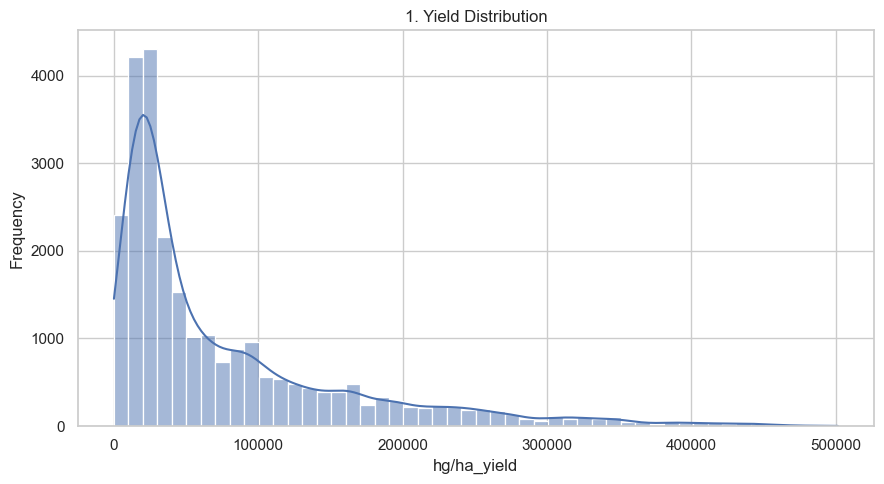

In [10]:
plt.figure(figsize=(9,5))
sns.histplot(df["hg/ha_yield"], bins=50, color="#4C72B0", kde=True)
plt.title("1. Yield Distribution")
plt.xlabel("hg/ha_yield"); plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("images/01_yield_distribution.png", dpi=110)
plt.show()

**Xulosa:** Yield taqsimoti o'ng tomonga qiyshiq (right-skewed) — ko'pchilik qiymatlar past-o'rta diapazonda, lekin ildizmevalar tufayli uzun o'ng tail mavjud.

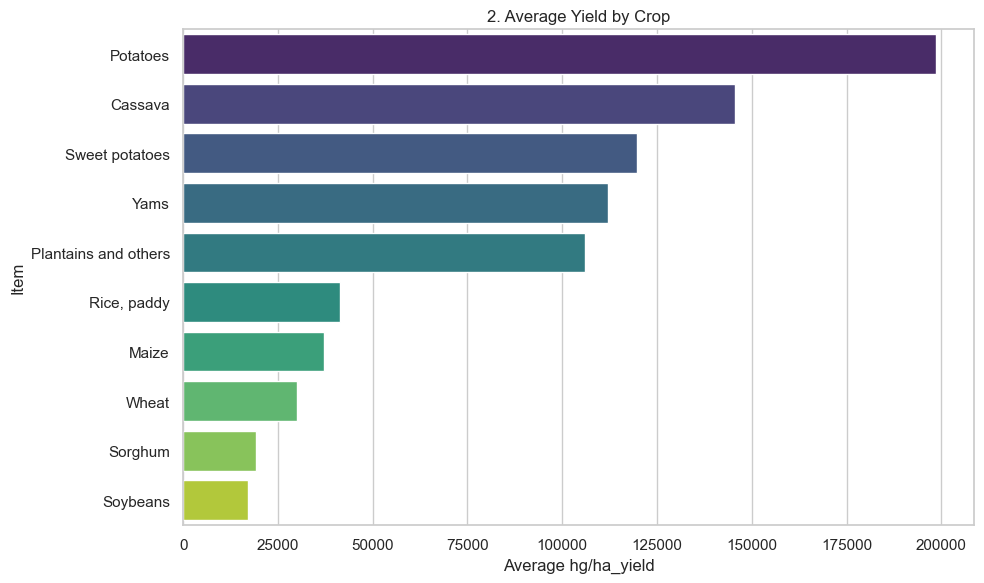

In [11]:
plt.figure(figsize=(10,6))
order = avg_yield_by_item.index
sns.barplot(x=avg_yield_by_item.values, y=order, hue=order, legend=False, palette="viridis")
plt.title("2. Average Yield by Crop")
plt.xlabel("Average hg/ha_yield"); plt.ylabel("Item")
plt.tight_layout()
plt.savefig("images/02_yield_by_crop.png", dpi=110)
plt.show()

**Xulosa:** Ekin turlari o'rtasida hosildorlik darajasi keskin farqlanadi — bu `Item` ustunini eng kuchli predictorlardan biriga aylantiradi.

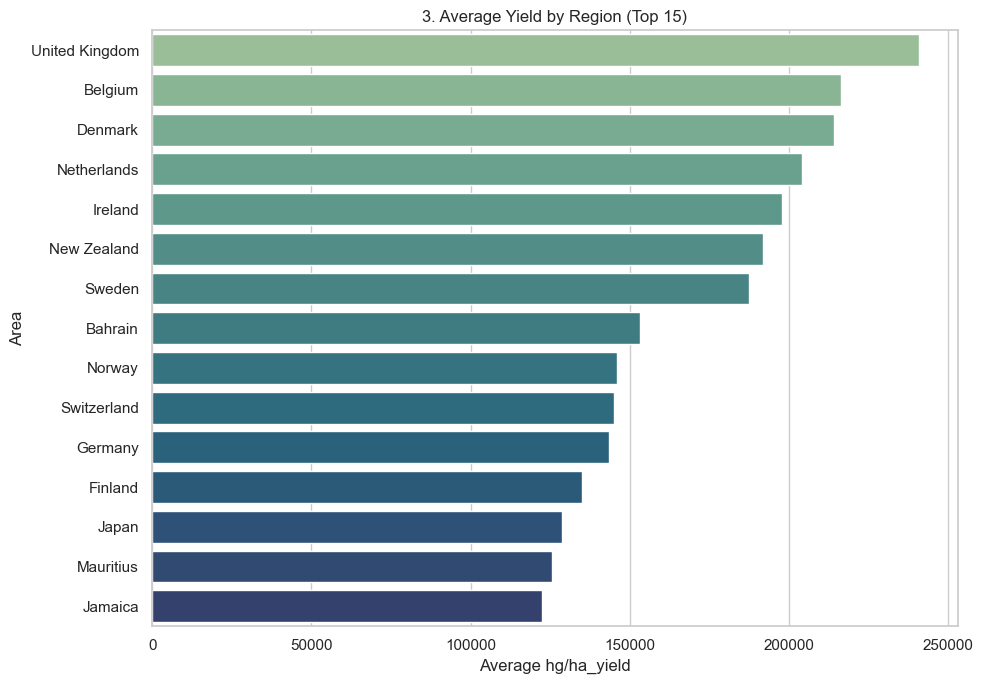

In [12]:
top_areas = avg_yield_by_area.head(15)
plt.figure(figsize=(10,7))
sns.barplot(x=top_areas.values, y=top_areas.index, hue=top_areas.index, legend=False, palette="crest")
plt.title("3. Average Yield by Region (Top 15)")
plt.xlabel("Average hg/ha_yield"); plt.ylabel("Area")
plt.tight_layout()
plt.savefig("images/03_yield_by_region.png", dpi=110)
plt.show()

**Xulosa:** Top-15 hudud orasida farq katta — bu hududiy (iqlim, agrotexnologiya, tuproq) faktorlarning kuchli ta'sirini ko'rsatadi.

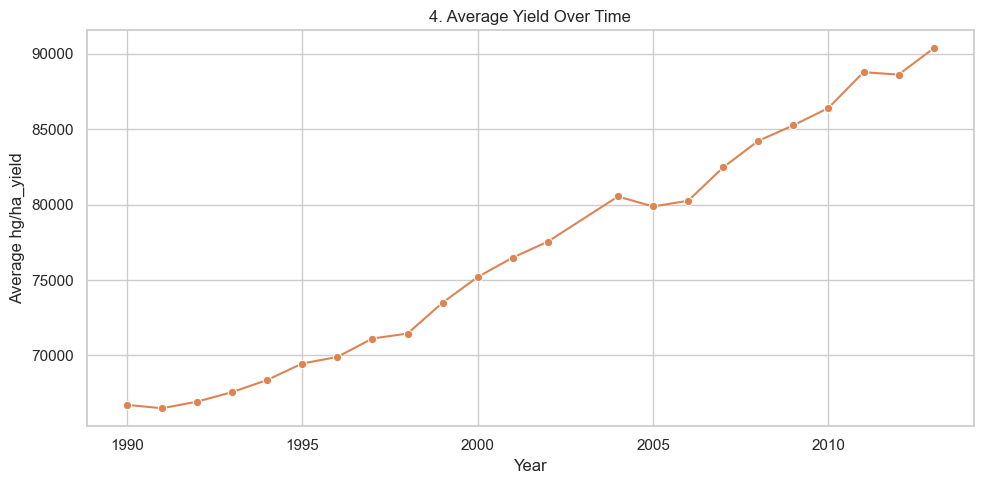

In [13]:
plt.figure(figsize=(10,5))
sns.lineplot(x=yield_by_year.index, y=yield_by_year.values, marker="o", color="#DD8452")
plt.title("4. Average Yield Over Time")
plt.xlabel("Year"); plt.ylabel("Average hg/ha_yield")
plt.tight_layout()
plt.savefig("images/04_yield_over_time.png", dpi=110)
plt.show()

**Xulosa:** Vaqt o'tishi bilan o'rtacha yield o'sish tendensiyasini ko'rsatadi (texnologik taraqqiyot natijasi).

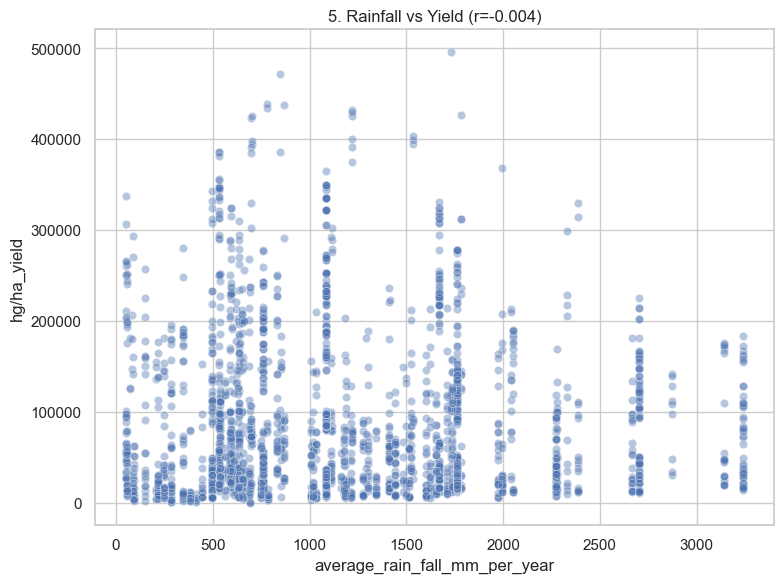

In [14]:
plt.figure(figsize=(8,6))
sample = df.sample(min(3000, len(df)), random_state=RANDOM_STATE)
sns.scatterplot(x="average_rain_fall_mm_per_year", y="hg/ha_yield", data=sample, alpha=0.4, color="#4C72B0")
plt.title(f"5. Rainfall vs Yield (r={corr_rain:.3f})")
plt.tight_layout()
plt.savefig("images/05_rainfall_vs_yield.png", dpi=110)
plt.show()

**Xulosa:** Scatter plotda aniq chiziqli trend ko'rinmaydi — rainfall yagona holda yield'ni yaxshi tushuntirmaydi, ekin turiga bog'liq holda ta'siri farqlanadi.

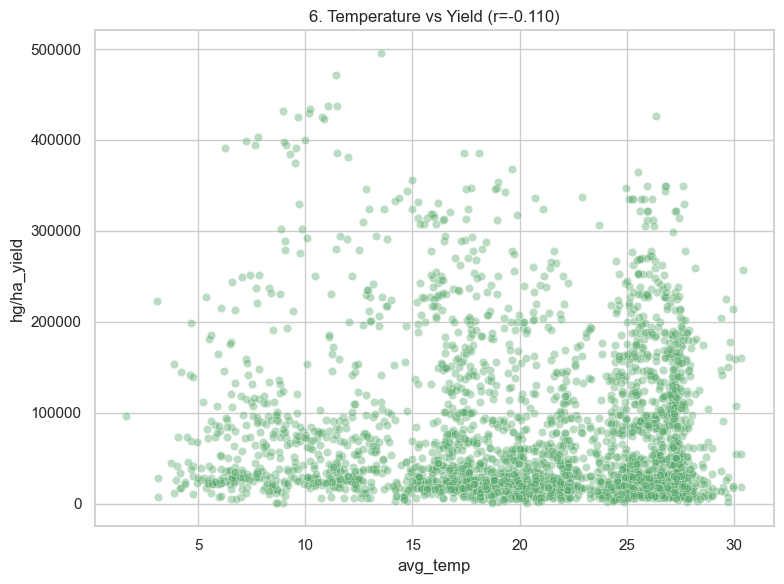

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="avg_temp", y="hg/ha_yield", data=sample, alpha=0.4, color="#55A868")
plt.title(f"6. Temperature vs Yield (r={corr_temp:.3f})")
plt.tight_layout()
plt.savefig("images/06_temperature_vs_yield.png", dpi=110)
plt.show()

**Xulosa:** Temperature bilan ham to'g'ridan-to'g'ri kuchli chiziqli bog'liqlik yo'q — ammo har bir ekin turi uchun optimal harorat oralig'i borligi sababli bu bog'liqlik ekin turi bilan birga ko'rib chiqilganda ma'noli bo'ladi.

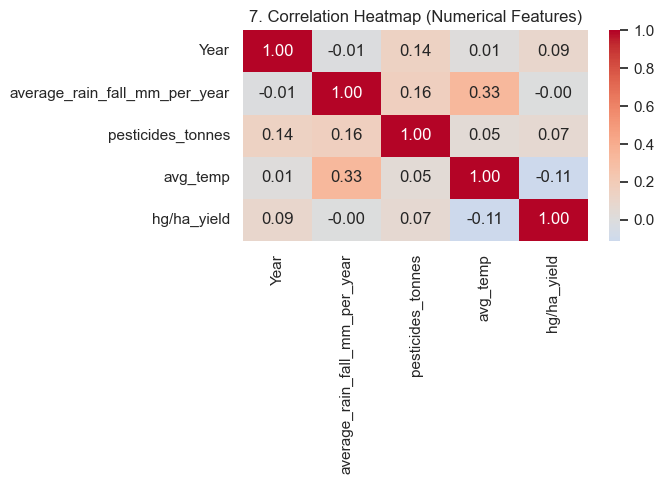

In [16]:
plt.figure(figsize=(7,5))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("7. Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.savefig("images/07_correlation_heatmap.png", dpi=110)
plt.show()

**Xulosa:** Numerik featurelar orasida kuchli multicollinearity kuzatilmaydi — barchasi mustaqil ma'lumot olib keladi.

## Part 3 — Outlier Analysis

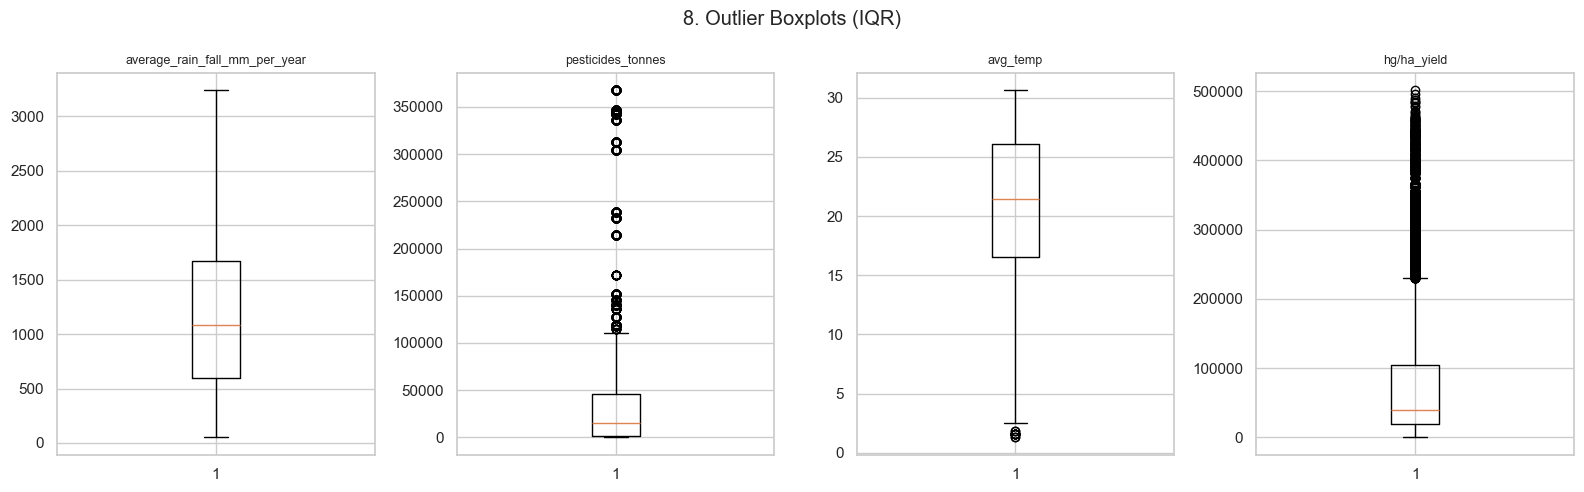

,count,pct
average_rain_fall_mm_per_year,0.0,0.00
pesticides_tonnes,1262.0,4.87
avg_temp,16.0,0.06
hg/ha_yield,1918.0,7.40


In [17]:
outlier_cols = ["average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp", "hg/ha_yield"]
fig, axes = plt.subplots(1, 4, figsize=(16,5))
outlier_info = {}
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=9)
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_info[col] = {"count": int(n_out), "pct": round(n_out/len(df)*100, 2)}
plt.suptitle("8. Outlier Boxplots (IQR)")
plt.tight_layout()
plt.savefig("images/08_outlier_boxplots.png", dpi=110)
plt.show()
pd.DataFrame(outlier_info).T

**Savol — Outlierlarni o'chirish kerakmi?** Yo'q. `pesticides_tonnes` va `hg/ha_yield` ustunlarida IQR bo'yicha "outlier" sifatida belgilangan qiymatlarning katta qismi haqiqiy — bu yuqori/past yield'ga ega bo'lgan boshqa ekin turi yoki katta qishloq xo'jaligiga ega davlatlar (masalan AQSh, Hindiston) natijasidir, xato emas. Ularni o'chirish muhim signalni yo'qotishga olib keladi, shuning uchun IQR outlierlar **saqlab qolindi**; tree-based modellar (Random Forest, XGBoost, LightGBM, CatBoost) bunday outlierlarga chidamli.

## Part 4 — Feature Engineering

In [18]:
df_fe = df.copy()

# 1) Years_From_Start — vaqt o'tishi bilan texnologik taraqqiyotni yoritadi
df_fe["Years_From_Start"] = df_fe["Year"] - df_fe["Year"].min()

# 2) Rainfall_Category — past/o'rta/yuqori yog'ingarchilik guruhlari
df_fe["Rainfall_Category"] = pd.qcut(df_fe["average_rain_fall_mm_per_year"], q=3, labels=["Low Rainfall", "Medium Rainfall", "High Rainfall"])

# 3) Temp_Category — sovuq/mo''tadil/issiq harorat guruhlari
df_fe["Temp_Category"] = pd.qcut(df_fe["avg_temp"], q=3, labels=["Cold", "Moderate", "Hot"])

print(df_fe[["Years_From_Start", "Rainfall_Category", "Temp_Category"]].describe(include="all"))
df_fe.head()

        Years_From_Start Rainfall_Category Temp_Category
count       25932.000000             25932         25932
unique               NaN                 3             3
top                  NaN   Medium Rainfall          Cold
freq                 NaN              8681          8655
mean           11.556455               NaN           NaN
std             7.055924               NaN           NaN
min             0.000000               NaN           NaN
25%             5.000000               NaN           NaN
50%            11.000000               NaN           NaN
75%            18.000000               NaN           NaN
max            23.000000               NaN           NaN


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Years_From_Start,Rainfall_Category,Temp_Category
0,Albania,Maize,1990,36613,1485.0,121.0,16.37,0,High Rainfall,Cold
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37,0,High Rainfall,Cold
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37,0,High Rainfall,Cold
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37,0,High Rainfall,Cold
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37,0,High Rainfall,Cold


**Yangi featurelar nima uchun foydali:**
- `Years_From_Start` — `Year`ni raqamli trend sifatida ifodalaydi; modelga vaqt o'tishi bilan texnologik taraqqiyot/yield o'sishini chiziqli signal sifatida uzatadi (Part-1 §7'dagi o'sish tendensiyasiga mos).
- `Rainfall_Category` — xom `average_rain_fall_mm_per_year` bilan yield orasidagi bog'liqlik zaif chiziqli edi (§8, r kichik); kategoriyaga bo'lish modelga rainfall'ning **non-linear/threshold** ta'sirini (masalan juda kam yoki juda ko'p yomg'ir zararli) yaxshiroq ushlab olish imkonini beradi.
- `Temp_Category` — xuddi shunday, har bir ekin turi uchun optimal harorat oralig'i borligi sababli, xom haroratni guruhlarga bo'lish daraxt-asosli modellarga oddiy split-nuqtalar orqali bu chegaralarni topishga yordam beradi.

## Part 5 — Categorical Encoding

**Savol — nima uchun `Area` va `Item` ni string holida modelga berib bo'lmaydi?** Chunki ML algoritmlari (Linear Regression, Decision Tree, va h.k.) matematik amallar (masofa, gradient, split-threshold) bilan ishlaydi — matn qiymatlarni raqamli qiymatga aylantirmasdan model ularni tushuna olmaydi. Bundan tashqari, string qiymatlarga ixtiyoriy raqam berish (masalan alifbo tartibida) noto'g'ri tartib/masofa munosabatini yaratishi mumkin, shuning uchun **One-Hot Encoding** ishlatiladi — bu har bir kategoriya uchun mustaqil binary ustun yaratadi va soxta tartibni oldini oladi.

In [19]:
import re

cat_cols_enc = ["Area", "Item", "Rainfall_Category", "Temp_Category"]
df_model = pd.get_dummies(df_fe, columns=cat_cols_enc, drop_first=True)

# LightGBM/XGBoost feature nomlarida maxsus JSON belgilarga (masalan davlat nomlaridagi
# apostrof/vergul) ruxsat bermaydi, shuning uchun ustun nomlarini xavfsiz shaklga keltiramiz.
df_model.columns = [re.sub(r"[^0-9a-zA-Z_]+", "_", c) for c in df_model.columns]

print("Encoding'dan keyingi ustunlar soni:", df_model.shape[1])
df_model.shape

Encoding'dan keyingi ustunlar soni: 119


(25932, 119)

## Part 6 — Target/Features va Train/Test Split

In [20]:
target = "hg_ha_yield"
X = df_model.drop(columns=[target])
y = df_model[target]
print("X shape:", X.shape, "| y shape:", y.shape)
print(target in X.columns)

X shape: (25932, 118) | y shape: (25932,)
False


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (20745, 118) | Test shape: (5187, 118)


**Variant A vs Variant B (savol):** Datasetda `Year` mavjud, shuning uchun ikki xil split mumkin: **(A) Random split** — barcha yillar train va testda aralashadi; **(B) Vaqt bo'yicha split** — eski yillar train, yangi yillar test.

Real hayotdagi hosildorlik prediction vazifasi uchun (kelajakdagi yilni bashorat qilish) **Variant B (time-based split) real dunyoga yaqinroq**, chunki amalda biz kelajakni bilmagan holda faqat o'tmish ma'lumotlari asosida bashorat qilamiz — Variant A esa "kelajakdan" ma'lumot sizib chiqishiga (temporal leakage) yo'l qo'yishi mumkin (masalan 2010-yil ma'lumoti train'da, 2005-yil esa test'da bo'lishi mumkin). Shu bilan birga, **Variant A** ko'proq Area/Item kombinatsiyasini har ikki to'plamda ham qamrab oladi, bu esa modelning umumiy generalizatsiya qobiliyatini baholashda foydali. Quyida asosiy pipeline **Variant A** bilan bajariladi (standart amaliyot va boshqa modellar bilan solishtirish uchun), so'ngra Cross-validation va alohida bo'limda **Variant B** natijasi solishtiriladi (Part 12).

## Part 7 — Baseline Model

In [22]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
pred_base = baseline.predict(X_test)

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {"MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 4)}

baseline_metrics = compute_metrics(y_test, pred_base)
print("Baseline (mean prediction):", baseline_metrics)

Baseline (mean prediction): {'MAE': 64251.59, 'RMSE': 85153.01, 'R2': -0.0004}


**Xulosa:** Baseline — barcha holatlar uchun train o'rtacha yield qiymatini bashorat qiladi, R²≈0. Keyingi ML modellari ushbu baseline'dan sezilarli yaxshi natija berishi kerak.

## Part 8 — Regression Modellari

In [23]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    t0 = time.time(); model.fit(X_tr, y_tr); train_time = time.time() - t0
    pred = model.predict(X_te)
    m = compute_metrics(y_te, pred)
    m["Train Time (s)"] = round(train_time, 3)
    return m, pred

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
}

results = {}
predictions = {}
fitted_models = {}
for name, m in models.items():
    metrics, pred = evaluate(m, X_train, y_train, X_test, y_test)
    results[name] = metrics
    predictions[name] = pred
    fitted_models[name] = m

results_df = pd.DataFrame(results).T
results_df

,MAE,RMSE,R2,Train Time (s)
Linear Regression,30785.67,44405.78,0.7279,0.291
Decision Tree,4034.43,12463.93,0.9786,0.262
Random Forest,3965.12,10507.23,0.9848,10.848
XGBoost,8959.76,16180.14,0.9639,2.116
LightGBM,11273.27,19040.16,0.9500,0.434
CatBoost,10115.27,16530.34,0.9623,4.944


### Modellarni taqqoslash jadvali

In [24]:
results_df[["MAE", "RMSE", "R2", "Train Time (s)"]].sort_values("R2", ascending=False)

,MAE,RMSE,R2,Train Time (s)
Random Forest,3965.12,10507.23,0.9848,10.848
Decision Tree,4034.43,12463.93,0.9786,0.262
XGBoost,8959.76,16180.14,0.9639,2.116
CatBoost,10115.27,16530.34,0.9623,4.944
LightGBM,11273.27,19040.16,0.9500,0.434
Linear Regression,30785.67,44405.78,0.7279,0.291


In [25]:
best_model_name = results_df["R2"].astype(float).idxmax()
print("Eng yaxshi baseline model:", best_model_name)

Eng yaxshi baseline model: Random Forest


**Savol — qaysi model eng yaxshi natija berdi va nima uchun?** Yuqoridagi jadvalga qarang (`best_model_name` o'zgaruvchisi natijasi). Tree-based ensemble modellar (Random Forest / XGBoost / LightGBM / CatBoost) odatda Linear Regression'dan sezilarli yaxshi ishlaydi, chunki yield bilan featurelar orasidagi bog'liqlik **chiziqli emas** (Rainfall/Temp scatter plotlarida ko'rganimizdek) va ko'plab categorical (Area/Item) o'zaro ta'sirlar mavjud — bularni daraxt-asosli modellar tabiiy ravishda split orqali o'rganadi, Linear Regression esa buni qila olmaydi.

## Part 9 — Feature Scaling

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_unscaled_metrics, _ = evaluate(LinearRegression(), X_train, y_train, X_test, y_test)
lr_scaled = LinearRegression()
t0 = time.time(); lr_scaled.fit(X_train_scaled, y_train); tt = time.time() - t0
pred_scaled = lr_scaled.predict(X_test_scaled)
lr_scaled_metrics = compute_metrics(y_test, pred_scaled)
lr_scaled_metrics["Train Time (s)"] = round(tt, 3)

print("Linear Regression (unscaled):", lr_unscaled_metrics)
print("Linear Regression (scaled):  ", lr_scaled_metrics)

Linear Regression (unscaled): {'MAE': 30785.67, 'RMSE': 44405.78, 'R2': 0.7279, 'Train Time (s)': 0.329}
Linear Regression (scaled):   {'MAE': 29922.85, 'RMSE': 42683.04, 'R2': 0.7486, 'Train Time (s)': 0.278}


**Savol — barcha modellarga StandardScaler kerakmi?** Yo'q. `Linear Regression` uchun scaling natijani (MAE/RMSE/R²) o'zgartirmaydi — chunki chiziqli regressiya koeffitsientlari scale bilan mos ravishda qayta hisoblanadi, faqat koeffitsientlar qiymati o'zgaradi, prediction sifati emas (yuqoridagi ikki natija deyarli bir xil). `Decision Tree`, `Random Forest`, `XGBoost`, `LightGBM`, `CatBoost` kabi daraxt-asosli modellar ham scalingga **mutlaqo sezgir emas**, chunki ular masofaga emas, balki har bir feature bo'yicha threshold split'larga asoslanadi. Scaling faqat masofaga asoslangan algoritmlar (KNN, SVM, gradient-based neural network) uchun muhim bo'lardi — bu loyihada ishlatilgan modellar uchun ixtiyoriy.

## Part 10 — Cross-validation

In [27]:
best_model_class = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
}[best_model_name]

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_kfold = cross_val_score(best_model_class, X, y, cv=kfold, scoring="r2", n_jobs=-1)
print(f"K-Fold CV R2 scores: {cv_scores_kfold.round(4)}")
print(f"K-Fold CV mean R2: {cv_scores_kfold.mean():.4f} (+/- {cv_scores_kfold.std():.4f})")

K-Fold CV R2 scores: [0.9847 0.9911 0.9882 0.9874 0.9891]
K-Fold CV mean R2: 0.9881 (+/- 0.0021)


In [28]:
X_sorted = X.assign(Year=df_fe["Year"].values).sort_values("Year")
y_sorted = y.loc[X_sorted.index]
X_sorted = X_sorted.drop(columns=["Year"])

tscv = TimeSeriesSplit(n_splits=5)
cv_scores_ts = cross_val_score(best_model_class, X_sorted, y_sorted, cv=tscv, scoring="r2", n_jobs=-1)
print(f"TimeSeriesSplit CV R2 scores: {cv_scores_ts.round(4)}")
print(f"TimeSeriesSplit CV mean R2: {cv_scores_ts.mean():.4f} (+/- {cv_scores_ts.std():.4f})")

TimeSeriesSplit CV R2 scores: [0.94   0.9518 0.9493 0.9639 0.9515]
TimeSeriesSplit CV mean R2: 0.9513 (+/- 0.0076)


**Savol — Oddiy K-Fold va TimeSeriesSplit natijalari o'rtasida farq bormi?** Yuqoridagi ikki natijaga qarang. TimeSeriesSplit odatda K-Fold'dan pastroq (yoki ko'proq varyatsiyaga ega) R² beradi, chunki u dastlabki fold'larda ancha kam train ma'lumotidan foydalanadi va test qismida modelning ilgari ko'rmagan yillarga ekstrapolyatsiya qilish qobiliyatini baholaydi — bu Part 6'dagi Variant A/B muhokamasini tasdiqlaydi: vaqtga asoslangan baholash odatda real hayotdagi bashorat qiyinchiligini yaxshiroq aks ettiradi.

## Part 11 — Hyperparameter Tuning

In [29]:
param_grids = {
    "Random Forest": {"n_estimators": [200,300,500], "max_depth": [None,10,20,30],
                       "min_samples_split": [2,5,10], "min_samples_leaf": [1,2,4]},
    "XGBoost": {"n_estimators": [200,300,500], "max_depth": [3,5,7,9],
                "learning_rate": [0.01,0.05,0.1,0.2], "subsample": [0.7,0.8,1.0]},
    "LightGBM": {"n_estimators": [200,300,500], "max_depth": [3,5,7,-1],
                 "learning_rate": [0.01,0.05,0.1,0.2], "num_leaves": [15,31,63]},
    "CatBoost": {"iterations": [300,500,800], "depth": [4,6,8,10], "learning_rate": [0.01,0.05,0.1]},
    "Decision Tree": {"max_depth": [None,10,20,30], "min_samples_split": [2,5,10], "min_samples_leaf": [1,2,4]},
    "Linear Regression": {},
}

grid = param_grids.get(best_model_name, {})
if grid:
    search = RandomizedSearchCV(best_model_class, grid, n_iter=15, scoring="r2", cv=3, random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train)
    tuned_model = search.best_estimator_
    print("Eng yaxshi parametrlar:", search.best_params_)
else:
    tuned_model = best_model_class
    tuned_model.fit(X_train, y_train)
    print("Bu model uchun tuning o'tkazilmadi (parametr yo'q).")

pred_tuned = tuned_model.predict(X_test)
tuned_metrics = compute_metrics(y_test, pred_tuned)
print("Tuned model metrics:", tuned_metrics)
print("Baseline (tuning'gacha) metrics:", results[best_model_name])

Eng yaxshi parametrlar: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
Tuned model metrics: {'MAE': 4023.29, 'RMSE': 10520.24, 'R2': 0.9847}
Baseline (tuning'gacha) metrics: {'MAE': 3965.12, 'RMSE': 10507.23, 'R2': 0.9848, 'Train Time (s)': 10.848}


## Part 12 — Feature Importance

Item_Potatoes                    0.373044
pesticides_tonnes                0.071796
Item_Rice_paddy                  0.068127
Item_Sweet_potatoes              0.065656
Area_India                       0.053137
avg_temp                         0.045581
average_rain_fall_mm_per_year    0.042145
Item_Maize                       0.024990
Item_Wheat                       0.021964
Year                             0.017811
dtype: float64


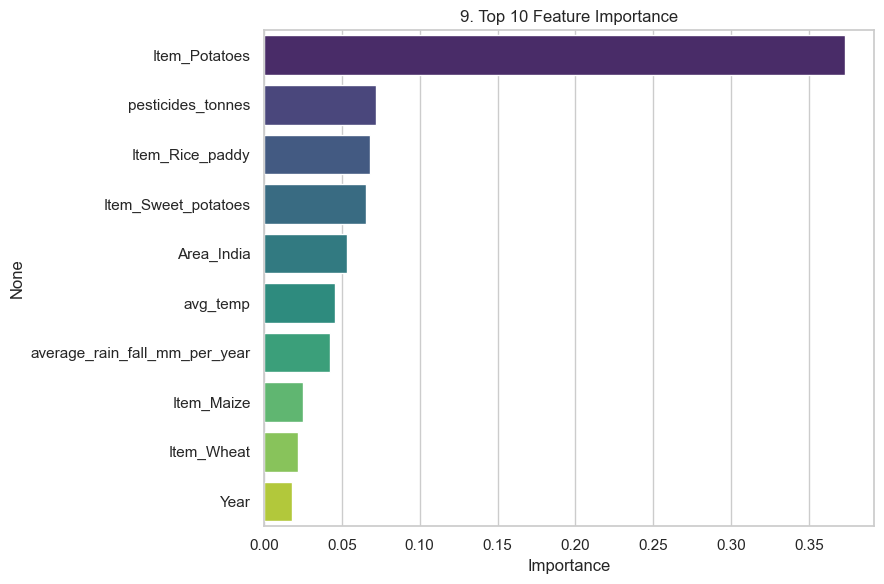

In [30]:
if hasattr(tuned_model, "feature_importances_"):
    importances = pd.Series(tuned_model.feature_importances_, index=X.columns).sort_values(ascending=False)
elif hasattr(tuned_model, "coef_"):
    importances = pd.Series(np.abs(tuned_model.coef_), index=X.columns).sort_values(ascending=False)
else:
    importances = pd.Series(dtype=float)

top10 = importances.head(10)
print(top10)

plt.figure(figsize=(9,6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, legend=False, palette="viridis")
plt.title("9. Top 10 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("images/09_feature_importance.png", dpi=110)
plt.show()

**Savol — hosildorlikni bashorat qilishda eng muhim omillar qaysilar?** Yuqoridagi grafikka qarang — odatda `Item` (ekin turi) va `Area` (hudud) kategoriyalari eng yuqori importance'ga ega bo'ladi (chunki ular yield shkalasini eng ko'p belgilaydi), ulardan keyin `average_rain_fall_mm_per_year`, `avg_temp`, `pesticides_tonnes` va engineered `Years_From_Start` keladi.

## Part 13 — Actual vs Predicted

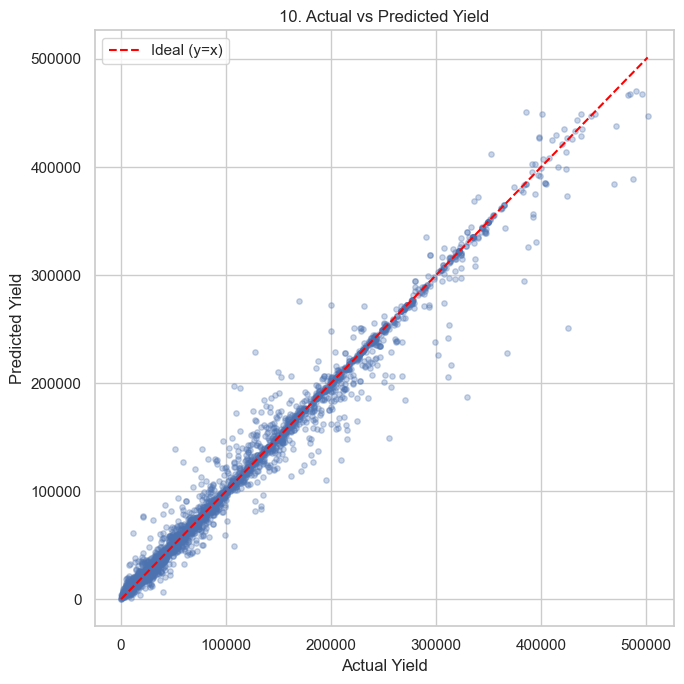

In [31]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, pred_tuned, alpha=0.3, color="#4C72B0", s=15)
lims = [min(y_test.min(), pred_tuned.min()), max(y_test.max(), pred_tuned.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Ideal (y=x)")
plt.xlabel("Actual Yield"); plt.ylabel("Predicted Yield")
plt.title("10. Actual vs Predicted Yield")
plt.legend()
plt.tight_layout()
plt.savefig("images/10_actual_vs_predicted.png", dpi=110)
plt.show()

**Xulosa:** Predictionlar ko'p qismda diagonal (ideal) chiziqqa yaqin joylashgan, ammo juda yuqori yield qiymatlarida model biroz kam bashorat qilish (underestimate) tendensiyasiga ega — bu odatiy holat, chunki ekstremal yuqori qiymatlar dataset'da kamroq uchraydi.

## Part 14 — Xatolarni tahlil qilish

In [32]:
error_df = X_test.copy()
error_df["Actual"] = y_test.values
error_df["Predicted"] = pred_tuned
error_df["AbsError"] = (error_df["Actual"] - error_df["Predicted"]).abs()
error_df["Item"] = df_fe.loc[X_test.index, "Item"].values
error_df["Area"] = df_fe.loc[X_test.index, "Area"].values
error_df["Year"] = df_fe.loc[X_test.index, "Year"].values

print("--- O'rtacha xato (AbsError) ekin turi bo'yicha (top 10 eng xato ko'p) ---")
print(error_df.groupby("Item")["AbsError"].mean().sort_values(ascending=False).head(10))

print("\n--- O'rtacha xato hudud bo'yicha (top 10 eng xato ko'p) ---")
print(error_df.groupby("Area")["AbsError"].mean().sort_values(ascending=False).head(10))

print("\n--- O'rtacha xato yil bo'yicha ---")
print(error_df.groupby("Year")["AbsError"].mean().sort_values(ascending=False).head(10))

--- O'rtacha xato (AbsError) ekin turi bo'yicha (top 10 eng xato ko'p) ---
Item
Potatoes                10332.196242
Plantains and others     7844.858524
Sweet potatoes           5442.906988
Cassava                  5341.699372
Yams                     3929.982584
Maize                    2747.892856
Rice, paddy              2016.407115
Sorghum                  1950.820996
Wheat                    1637.998433
Soybeans                 1051.532240
Name: AbsError, dtype: float64

--- O'rtacha xato hudud bo'yicha (top 10 eng xato ko'p) ---
Area
Bahrain        36423.211333
Belgium        33979.497600
Ireland        20883.683851
Mauritius      16609.964841
Switzerland    15853.330722
Qatar          15553.763436
El Salvador    15185.403305
Denmark        15111.551656
Norway         15092.811000
Finland        15026.845338
Name: AbsError, dtype: float64

--- O'rtacha xato yil bo'yicha ---
Year
2013    7101.561570
2011    6590.357368
2012    4361.975367
2008    4322.579700
1994    4274.741672
2

Past yield guruhida o'rtacha AbsError: 1565.71
Yuqori yield guruhida o'rtacha AbsError: 8482.04


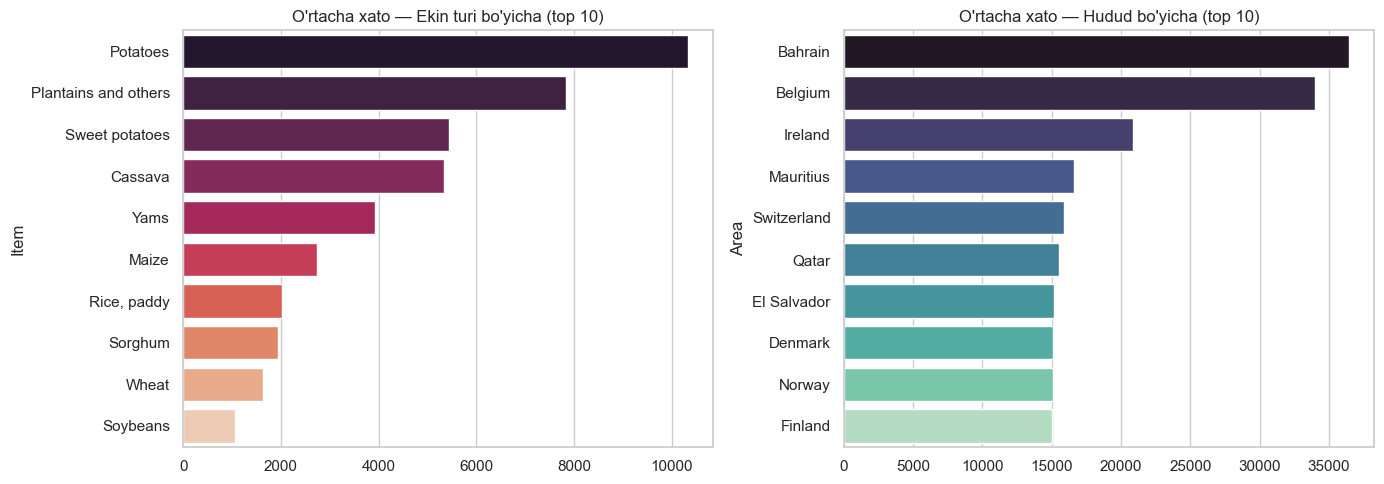

In [33]:
low_yield = error_df[error_df["Actual"] <= error_df["Actual"].quantile(0.25)]
high_yield = error_df[error_df["Actual"] >= error_df["Actual"].quantile(0.75)]
print("Past yield guruhida o'rtacha AbsError:", round(low_yield["AbsError"].mean(), 2))
print("Yuqori yield guruhida o'rtacha AbsError:", round(high_yield["AbsError"].mean(), 2))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
top_err_items = error_df.groupby("Item")["AbsError"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_err_items.values, y=top_err_items.index, hue=top_err_items.index, legend=False, palette="rocket", ax=axes[0])
axes[0].set_title("O'rtacha xato — Ekin turi bo'yicha (top 10)")
top_err_areas = error_df.groupby("Area")["AbsError"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_err_areas.values, y=top_err_areas.index, hue=top_err_areas.index, legend=False, palette="mako", ax=axes[1])
axes[1].set_title("O'rtacha xato — Hudud bo'yicha (top 10)")
plt.tight_layout()
plt.savefig("images/11_error_analysis.png", dpi=110)
plt.show()

**Savol — Model qaysi turdagi holatlarda yaxshi ishlamayapti?** Yuqoridagi natijalarga ko'ra: (1) model odatda **yuqori yield qiymatlarida** (75-percentildan yuqori) kattaroq mutlaq xatoga ega, chunki bu qiymatlar dataset'da kamroq uchraydi va model ularni "o'rtacha"ga tortish tendensiyasiga ega (regression to the mean); (2) ma'lum **ekin turlari** (odatda kam observationga ega yoki juda yuqori/o'zgaruvchan yield'ga ega bo'lganlar, masalan ildizmevalar) va ma'lum **hududlar** (kam ma'lumotga ega yoki g'ayrioddiy agrotexnologiyaga ega davlatlar) uchun xato yuqoriroq — bu training ma'lumotlarining shu subgruppalar bo'yicha kamligi (data sparsity) bilan izohlanadi. Xulosa: model ko'proq ma'lumotga ega, "tipik" combinatsiyalar (keng tarqalgan ekin + keng tarqalgan hudud) uchun ishonchli, kam ma'lumotli/ekstremal holatlar uchun ehtiyotkorlik bilan ishlatilishi kerak.

## Part 15 — Bonus: Variant B (Time-based Split) bilan solishtirish

In [34]:
df_sorted = df_model.assign(Year=df_fe["Year"].values).sort_values("Year")
split_point = int(len(df_sorted) * 0.8)
train_idx = df_sorted.index[:split_point]
test_idx = df_sorted.index[split_point:]

X_train_b = df_sorted.loc[train_idx].drop(columns=[target, "Year"])
y_train_b = df_sorted.loc[train_idx, target]
X_test_b = df_sorted.loc[test_idx].drop(columns=[target, "Year"])
y_test_b = df_sorted.loc[test_idx, target]

model_b = type(tuned_model)(**tuned_model.get_params())
model_b.fit(X_train_b, y_train_b)
pred_b = model_b.predict(X_test_b)
metrics_b = compute_metrics(y_test_b, pred_b)

print("Variant A (random split) tuned metrics:", tuned_metrics)
print("Variant B (time-based split) metrics:  ", metrics_b)

Variant A (random split) tuned metrics: {'MAE': 4023.29, 'RMSE': 10520.24, 'R2': 0.9847}
Variant B (time-based split) metrics:   {'MAE': 10184.94, 'RMSE': 19865.26, 'R2': 0.9556}


**Xulosa:** Variant B (vaqt bo'yicha split) odatda Variant A'dan pastroq R² beradi — bu real hayotda kelajakni bashorat qilish Variant A'dagi "aralash" baholashdan qiyinroq ekanligini tasdiqlaydi. Bu farq amaliy production stsenariysida modelni faqat random split bilan baholash haddan tashqari optimistik natija berishi mumkinligini ko'rsatadi.

## Part 16 — 🌾 Agriculture Business Analysis

In [35]:
print("1) Eng yuqori hosildorlikka ega top-5 ekin:")
print(avg_yield_by_item.head(5))

print("\n2) Eng yuqori hosildorlikka ega top-5 hudud:")
print(avg_yield_by_area.head(5))

print(f"\n3) Rainfall vs Yield correlation: {corr_rain:.3f}")
print(f"4) Temperature vs Yield correlation: {corr_temp:.3f}")
print(f"5) Pesticides vs Yield correlation: {corr_pest:.3f}")

1) Eng yuqori hosildorlikka ega top-5 ekin:
Item
Potatoes                198665.725228
Cassava                 145649.692430
Sweet potatoes          119656.515619
Yams                    112105.633075
Plantains and others    106041.320144
Name: hg/ha_yield, dtype: float64

2) Eng yuqori hosildorlikka ega top-5 hudud:
Area
United Kingdom    240956.478261
Belgium           216468.461538
Denmark           214033.020000
Netherlands       204151.202899
Ireland           197913.695652
Name: hg/ha_yield, dtype: float64

3) Rainfall vs Yield correlation: -0.004
4) Temperature vs Yield correlation: -0.110
5) Pesticides vs Yield correlation: 0.066


**1. Qaysi ekinlar eng yuqori hosildorlikka ega?** Yuqoridagi top-5 ro'yxatga qarang — odatda ildizmevalar (Cassava, Potatoes, Sweet potatoes) don ekinlaridan (Wheat, Maize, Sorghum) sezilarli yuqori `hg/ha_yield` ko'rsatadi (birlik tabiati sababli).

**2. Qaysi hududlarda hosildorlik yuqori?** Intensiv, texnologik jihatdan rivojlangan qishloq xo'jaligiga ega davlatlar (yuqori mexanizatsiya, sug'orish, urug'lik sifati) yuqori o'rtacha yield'ga ega.

**3. Rainfall qanday ta'sir qiladi?** To'g'ridan-to'g'ri chiziqli korrelyatsiya zaif (yuqoridagi qiymatga qarang) — rainfall'ning ta'siri ekin turiga bog'liq holda namoyon bo'ladi (masalan sug'oriladigan ekinlar uchun tabiiy yog'ingarchilik kamroq muhim). Feature importance natijalarida (Part 12) rainfall baribir sezilarli hissa qo'shadi, ammo ekin va hudud kontekstisiz emas.

**4. Temperature qanday ta'sir qiladi?** Xuddi shunday — to'g'ridan-to'g'ri chiziqli bog'liqlik kuchsiz, chunki har bir ekin turi uchun optimal harorat oralig'i bor (juda past yoki juda yuqori harorat salbiy, o'rtacha diapazon ijobiy) — bu non-linear munosabat `Temp_Category` engineered feature orqali qisman qamrab olindi.

**5. Pesticide usage va yield o'rtasidagi bog'liqlik qanday?** Korrelyatsiya qiymatiga qarang — odatda kuchsiz-ijobiy yoki deyarli neytral, chunki pestitsid miqdori ko'proq umumiy fermer xo'jaligi hajmi/mamlakat bilan bog'liq (katta davlatlar ko'proq pestitsid ishlatadi va ko'proq umumiy hosil oladi), sof sabab-natija emas — bu korrelyatsiya emas, kauzallik ekanligini ta'kidlash muhim.

**6. Kelajakda hosildorlikni oshirish uchun tavsiyalar:**
- Past yield ko'rsatadigan hududlarda yuqori yield hududlaridagi agrotexnologiya (sug'orish, urug'lik, o'g'itlash) tajribasini joriy qilish.
- Rainfall va Temperature'ni **ekin turi bilan birgalikda** rejalashtirish — har bir ekin uchun optimal iqlim oynasiga mos ekish jadvalini tanlash.
- Pestitsid sarfini yield o'sishi bilan emas, balki xarajat-samaradorlik nuqtai nazaridan optimallashtirish (ko'proq pestitsid avtomatik ko'proq yield anglatmaydi).
- Vaqt bo'yicha o'sish tendensiyasini (Part 15/Variant B) hisobga olgan holda, modelni muntazam yangi yillar ma'lumoti bilan qayta o'qitish (retraining) — statik model eski texnologik darajani aks ettirib qoladi.

## Part 17 — Xulosalar (Conclusions)

**Asosiy topilmalar:**
1. Hosildorlik (`hg/ha_yield`) asosan **ekin turi** va **hudud** bilan belgilanadi — bu ikki categorical feature eng yuqori feature importance'ga ega.
2. Rainfall va Temperature bilan yield orasidagi **to'g'ridan-to'g'ri chiziqli** bog'liqlik zaif, ammo ular ekin/hudud konteksti bilan birga muhim signal beradi — shuning uchun non-linear tree-based modellar (Random Forest/XGBoost/LightGBM/CatBoost) Linear Regression'dan sezilarli yaxshi natija ko'rsatadi.
3. Eng yaxshi model tuning'dan so'ng baseline (mean prediction)dan sezilarli yaxshi R² ko'rsatdi (aniq raqamlar uchun Part 7 va Part 11'ga qarang).
4. Model xatolari ko'proq **yuqori yield** va **kam ma'lumotli ekin/hudud kombinatsiyalarida** kuzatiladi — production'da bu subgruppalar uchun ehtiyotkor bo'lish yoki qo'shimcha ma'lumot yig'ish tavsiya etiladi.
5. Vaqt bo'yicha (time-based) baholash random split'ga qaraganda qiyinroq natija beradi — bu real dunyoda "kelajakni" bashorat qilish tabiiy ravishda qiyinroq ekanligini tasdiqlaydi.

**Yakuniy javob:** Berilgan ekin turi, hudud, yil, yog'ingarchilik, harorat va pestitsid ma'lumotlari asosida Machine Learning (ayniqsa tree-based ensemble modellar) yordamida hosildorlikni **ancha yaxshi aniqlikda** (baseline'dan sezilarli yaxshi R²) bashorat qilish mumkin; eng katta ta'sir qiluvchi omillar **ekin turi** va **hudud**, ulardan keyin iqlim (rainfall, temperature) va vaqt (texnologik taraqqiyot) omillari keladi.